In [8]:
import os
import random
import librosa
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch

from transformers import Wav2Vec2Processor
from transformers import Wav2Vec2Model

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import pairwise_distances

In [9]:
dataset_path = r"speech_commands_v0.02"

In [15]:
# Loading few classes of sample data
audio_files = []
labels = []
classes = ["yes", "no", "up", "down", "left", "right"]
for cls in classes:
    folder = os.path.join(dataset_path, cls)
    wav_files = [f for f in os.listdir(folder) if f.endswith(".wav")]
    file = random.choice(wav_files)
    audio_files.append(os.path.join(folder, file))
    labels.append(cls)
print(labels)

['yes', 'no', 'up', 'down', 'left', 'right']


In [16]:
# Loading the audio file from the few classes processed above
signals = []
for file in audio_files:
    signal, sr = librosa.load(file,sr=16000)
    signals.append(signal)

In [17]:
#Loading pre-trained model WavVec2
processor = Wav2Vec2Processor.from_pretrained("facebook/wav2vec2-base-960h")

model = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base-960h")

model.eval()

D:\jupyter_python\AI_ML repo\Week 4\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MADHUMITA\.cache\huggingface\hub\models--facebook--wav2vec2-base-960h. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 210/210 [00:00<00:00, 4216.31it/s]
[transformers] Wav2Vec2Mod

Wav2Vec2Model(
  (feature_extractor): Wav2Vec2FeatureEncoder(
    (conv_layers): ModuleList(
      (0): Wav2Vec2GroupNormConvLayer(
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
        (activation): GELUActivation()
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True, bias=True)
      )
      (1-4): 4 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
      (5-6): 2 x Wav2Vec2NoLayerNormConvLayer(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
        (activation): GELUActivation()
      )
    )
  )
  (feature_projection): Wav2Vec2FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True, bias=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): Wav2Vec2Encoder(
    (pos_conv_embed): Wav2Vec2Posit

In [18]:
# Extracting embeddings
embeddings = []
for signal in signals:
    inputs = processor(
        signal,
        sampling_rate=16000,
        return_tensors="pt",
        padding=True)
    with torch.no_grad():
        outputs = model(**inputs)
    embedding = outputs.last_hidden_state.mean(dim=1)
    embeddings.append(embedding.squeeze().numpy())
embeddings = np.array(embeddings)
print(embeddings.shape)

(6, 768)


In [20]:
# Pairwise similarity and distance Matrix
similarity = cosine_similarity(embeddings)
print(f"Similarity: \n{similarity}")

# Euclidean distance
distance = pairwise_distances(embeddings,metric="euclidean")
print(f'Euclidean Distance: \n{distance}')

Similarity: 
[[1.         0.84719586 0.8254753  0.8391029  0.94603634 0.87972987]
 [0.84719586 1.         0.94228816 0.9784423  0.89427555 0.944956  ]
 [0.8254753  0.94228816 1.0000001  0.94196385 0.85884583 0.95048034]
 [0.8391029  0.9784423  0.94196385 0.9999999  0.89501345 0.94915974]
 [0.94603634 0.89427555 0.85884583 0.89501345 1.0000002  0.90436834]
 [0.87972987 0.944956   0.95048034 0.94915974 0.90436834 0.99999964]]
Euclidean Distance: 
[[0.        3.745968  4.2955394 3.5134263 1.472968  3.307712 ]
 [3.745968  0.        2.3888977 1.3952581 3.2938275 2.1805747]
 [4.2955394 2.3888977 0.        2.437734  3.984394  2.24426  ]
 [3.5134263 1.3952581 2.437734  0.        2.9895897 2.02959  ]
 [1.472968  3.2938275 3.984394  2.9895897 0.        3.0257816]
 [3.307712  2.1805747 2.24426   2.02959   3.0257816 0.       ]]


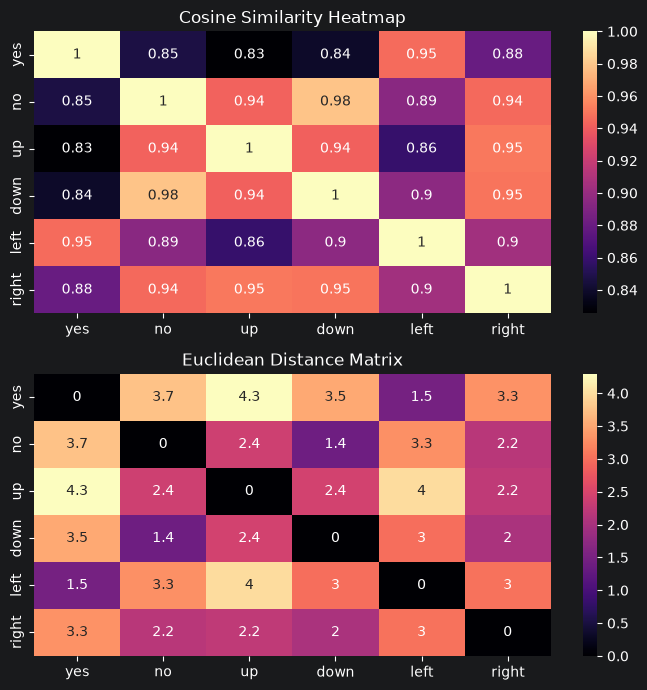

In [24]:
# Similarity Heatmap
plt.figure(figsize=(7,7))

plt.subplot(2,1,1)
sns.heatmap(similarity,annot=True,cmap="magma",
    xticklabels=labels, yticklabels=labels)
plt.title("Cosine Similarity Heatmap")

plt.subplot(2,1,2)
sns.heatmap(distance,annot=True,cmap="magma",
    xticklabels=labels,yticklabels=labels)
plt.title("Euclidean Distance Matrix")

plt.tight_layout()
plt.show()

1. Similar audio clips produce embeddings with higher cosine similarity.
2. Euclidean distance is smaller for acoustically similar commands.
3. Wav2Vec2 captures speech characteristics effectively without any training.